<a href="https://colab.research.google.com/github/Saloni-Shaw/Data-Analytics-Projects/blob/main/Revenue_%26_Profit_Optimization_Analysis_for_Retail_Business.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Retail Sales & Profit Analysis

## Objective
The objective of this project is to analyze retail sales data to identify key revenue drivers, profitability patterns, and the impact of discount strategies on business performance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
upload=files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
df=pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Dataset Overview

The dataset contains information about retail orders including product categories, sales, profit, discount, and customer segments.

It includes 9,994 records and 21 variables such as:
- Order Date
- Region
- Category
- Sales
- Profit
- Discount

This data allows analysis of sales trends, profitability, and customer segments.

In [ ]:
df.shape

(9994, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
print(df["Sales"].sum())

2297200.8603000003


###Total Revenue
The company generated a total revenue of $2.29 millio during the record period.
This provides an overall understanding of the company's scale of operations

In [ ]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


###Revenue by Region
The west region generates the highest revenue among all regions,followed by East and central.
The south region contributes the lowest revenue, indicating potential opportunities for market expansion in this area.


In [ ]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


### Revenue by Category

Technology generates the highest revenue among all product categories.

Furniture and Office Supplies also contribute significantly, but Technology remains the primary revenue driver.

In [ ]:
df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


### Revenue by Customer Segment
The consumer segment contributes the highest share of total revenue.
Corporate customers also generate significant revenue , while the Home office segment contributes comparatively less.

In [ ]:
df["Profit"].sum()

np.float64(286397.0217)

###Total Profit

The company generated a total profit of $2863 during the observed period


In [ ]:
df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


###Profit by Region
The west region generates the highest profit,while the Central region shows comparatively lower profitability.
This suggests stronger business performance in west region.

In [ ]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


Technology products generates the highest profit, while the furniture category contributes the least.
This suggests the technology provide better margins.

In [ ]:
df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


Certain sub-categories such as phones and copiers generate a strong profits.
However , products like tables and Bookcases show negative profit, indicating potential loss making product lines.

In [ ]:
df[df["Profit"]<0].head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
14,15,US-2015-118983,11/22/2015,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580
15,16,US-2015-118983,11/22/2015,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160
23,24,US-2017-156909,7/16/2017,7/18/2017,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
27,28,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522


In [ ]:
(df["Profit"]<0).sum()

np.int64(1871)

In [ ]:
df["Profit Margin"]=df["Profit"]/df["Sales"]*100
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,16.00
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,30.00
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,47.00
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-40.00
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.25


In [ ]:
df.groupby("Discount")["Profit"].mean().sort_values()

,Profit
Discount,
0.50,-310.703456
0.45,-226.646464
0.40,-111.927429
0.80,-101.796797
0.70,-95.874060
0.32,-88.560656
0.30,-45.679636
0.60,-43.077212
0.20,24.702572


### Discount Impact on Profit

The analysis shows a strong negative relationship between discount levels and profitability.

Orders with low discounts (0–10%) generate the highest average profits.

However, as discount levels increase beyond 30%, the average profit becomes negative, indicating that excessive discounting leads to financial losses.

This suggests that the company should carefully monitor discount strategies to avoid profit erosion.

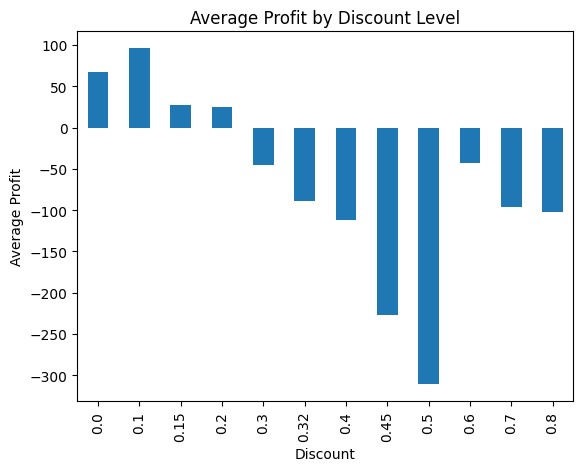

In [ ]:
import matplotlib.pyplot as plt

df.groupby("Discount")["Profit"].mean().plot(kind="bar")
plt.title("Average Profit by Discount Level")
plt.ylabel("Average Profit")
plt.xlabel("Discount")
plt.show()

## Data Cleaning

- Converted Order Date into datetime format.
- Created Year and Month columns for time trend analysis.
- Checked for missing values.
- Ensured numeric columns were properly formatted.

In [ ]:
df["Order Date"]=pd.to_datetime(df["Order Date"])


In [ ]:
df["Year"]=df["Order Date"].dt.year
df["Month"]=df["Order Date"].dt.month
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Year,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,16.00,2016,11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,30.00,2016,11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,47.00,2016,6
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-40.00,2015,10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.25,2015,10


In [ ]:
df.groupby("Year")["Sales"].sum().sort_values(ascending=False)

,Sales
Year,
2017,733215.2552
2016,609205.5980
2014,484247.4981
2015,470532.5090


### Sales Trend by Year

Sales show a steady increase from 2014 to 2017, indicating consistent business growth over the observed period.


In [ ]:
monthly_sales=df.groupby("Month")["Sales"].sum().sort_values(ascending=False)
monthly_sales

,Sales
Month,
11,352461.0710
12,325293.5035
9,307649.9457
3,205005.4888
10,200322.9847
8,159044.0630
5,155028.8117
6,152718.6793
7,147238.0970


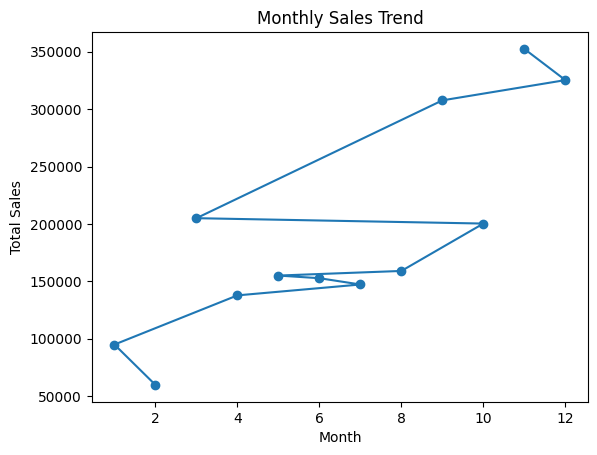

In [ ]:
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

### Monthly Sales Trend

Sales show noticeable peaks during certain months, particularly towards the end of the year. This suggests seasonal demand patterns, likely driven by holiday shopping periods.

### Conclusion

1. Technology products generate the highest profit.
2. Certain sub-categories such as Tables result in negative profits.
3. Higher discounts significantly reduce profitability.
4. Sales show seasonal peaks towards the end of the year.